# Notebook Review Folds

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

SPLIT_DIR = (
    PROJECT_ROOT
    / "metadata"
    / "splits"
)

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "splitting"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Reading data

In [2]:
mapping = pd.read_csv(
    SPLIT_DIR
    / "chbmit_resolved_subject_mapping.csv"
)

subject_summary = pd.read_csv(
    SPLIT_DIR
    / "chbmit_subject_summary.csv"
)

outer = pd.read_csv(
    SPLIT_DIR
    / "chbmit_outer_subject_folds.csv"
)

inner = pd.read_csv(
    SPLIT_DIR
    / "chbmit_inner_subject_folds.csv"
)

windows = pd.read_csv(
    SPLIT_DIR
    / "chbmit_window_outer_folds.csv"
)

outer_summary = pd.read_csv(
    SPLIT_DIR
    / "chbmit_outer_fold_summary.csv"
)

# Control chb01 and chb21

In [3]:
mapping.loc[
    mapping["case_id"].isin(
        ["chb01", "chb21"]
    )
]

,case_id,subject_id,mapping_status,mapping_source,notes
0,chb01,subject_chb01_chb21,verified,PhysioNet CHB-MIT description,Same subject as chb21
19,chb21,subject_chb01_chb21,verified,PhysioNet CHB-MIT description,Same subject as chb01 approximately 1.5 years ...


In [4]:
(
    mapping.loc[
        mapping["case_id"].isin(
            ["chb01", "chb21"]
        )
    ]
    .merge(
        outer,
        on="subject_id",
        validate="many_to_one",
    )
)

,case_id,subject_id,mapping_status,mapping_source,notes,outer_test_fold,splitting_version,outer_random_state,git_commit,split_timestamp_utc
0,chb01,subject_chb01_chb21,verified,PhysioNet CHB-MIT description,Same subject as chb21,0,splitting_v1,42,583793b773a95c3e586da5406aafb5e7a97f33d5,2026-08-04T16:13:23.228310+00:00
1,chb21,subject_chb01_chb21,verified,PhysioNet CHB-MIT description,Same subject as chb01 approximately 1.5 years ...,0,splitting_v1,42,583793b773a95c3e586da5406aafb5e7a97f33d5,2026-08-04T16:13:23.228310+00:00


# Number of Subjects in Outer Folds

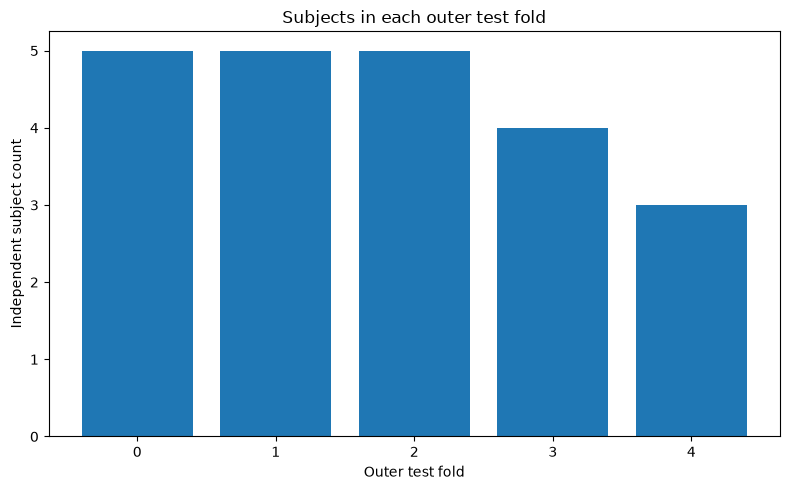

In [5]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    outer_summary[
        "outer_test_fold"
    ].astype(str),
    outer_summary[
        "subject_count"
    ],
)

ax.set_xlabel("Outer test fold")
ax.set_ylabel("Independent subject count")
ax.set_title(
    "Subjects in each outer test fold"
)

fig.tight_layout()
fig.savefig(
    REPORT_DIR
    / "outer_fold_subject_counts.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Number of Windows

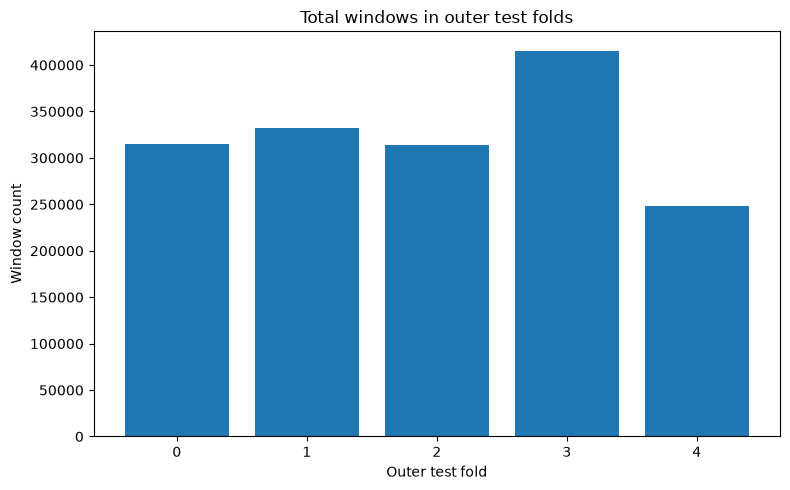

In [6]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    outer_summary[
        "outer_test_fold"
    ].astype(str),
    outer_summary[
        "total_window_count"
    ],
)

ax.set_xlabel("Outer test fold")
ax.set_ylabel("Window count")
ax.set_title(
    "Total windows in outer test folds"
)

fig.tight_layout()
fig.savefig(
    REPORT_DIR
    / "outer_fold_window_counts.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Number of Ictal Windows

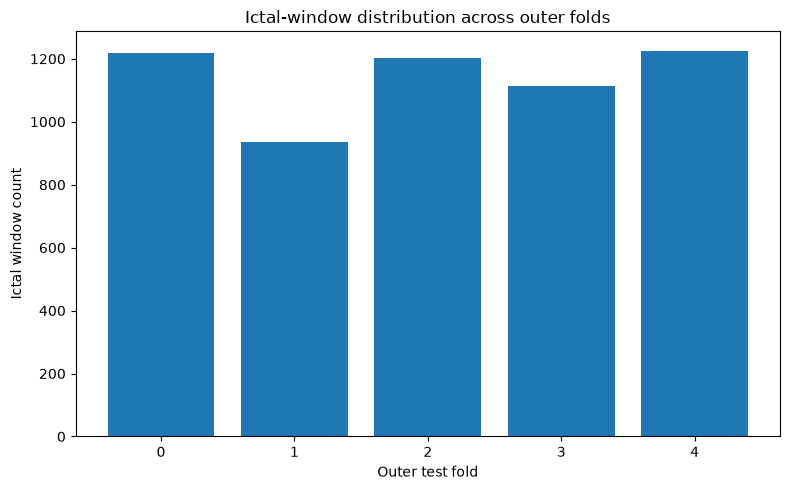

In [7]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    outer_summary[
        "outer_test_fold"
    ].astype(str),
    outer_summary[
        "ictal_window_count"
    ],
)

ax.set_xlabel("Outer test fold")
ax.set_ylabel("Ictal window count")
ax.set_title(
    "Ictal-window distribution across outer folds"
)

fig.tight_layout()
fig.savefig(
    REPORT_DIR
    / "outer_fold_ictal_counts.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Class Ratio

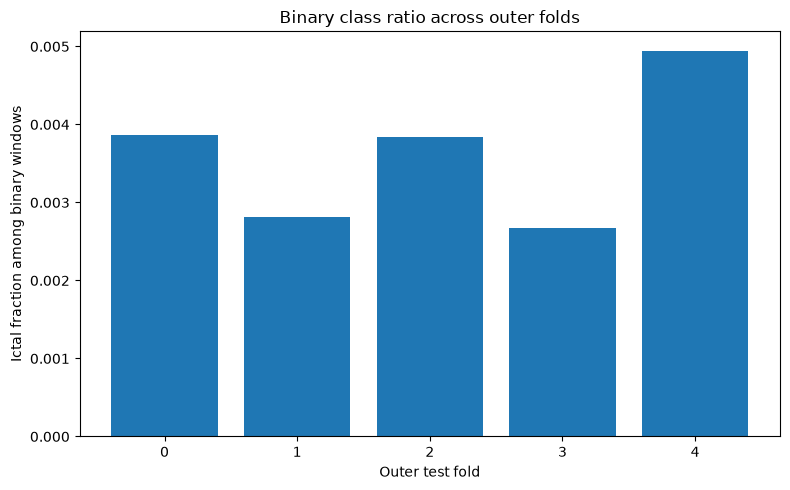

In [8]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    outer_summary[
        "outer_test_fold"
    ].astype(str),
    outer_summary[
        "ictal_window_fraction"
    ],
)

ax.set_xlabel("Outer test fold")
ax.set_ylabel(
    "Ictal fraction among binary windows"
)
ax.set_title(
    "Binary class ratio across outer folds"
)

fig.tight_layout()
fig.savefig(
    REPORT_DIR
    / "outer_fold_class_ratio.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Creating a Loader for a Nested Fold

In [9]:
def get_nested_fold_windows(
    windows: pd.DataFrame,
    inner_assignments: pd.DataFrame,
    outer_fold: int,
    inner_fold: int,
) -> dict[str, pd.DataFrame]:
    current = inner_assignments.loc[
        (
            inner_assignments[
                "outer_fold"
            ]
            == outer_fold
        )
        & (
            inner_assignments[
                "inner_fold"
            ]
            == inner_fold
        )
    ]

    output = {}

    for role in [
        "train",
        "validation",
        "test",
    ]:
        subjects = set(
            current.loc[
                current["role"] == role,
                "subject_id",
            ]
        )

        output[role] = windows.loc[
            windows["subject_id"].isin(
                subjects
            )
        ].copy()

    return output

In [10]:
folds = get_nested_fold_windows(
    windows=windows,
    inner_assignments=inner,
    outer_fold=0,
    inner_fold=0,
)

for role, table in folds.items():
    print(
        role,
        table["subject_id"].nunique(),
        len(table),
        table["label_name"].value_counts().to_dict(),
    )

train 13 893901 {'non_ictal': 890536, 'ictal': 3365}
validation 4 415536 {'non_ictal': 414423, 'ictal': 1113}
test 5 314864 {'non_ictal': 313646, 'ictal': 1218}


In [11]:
train_subjects = set(
    folds["train"]["subject_id"]
)

validation_subjects = set(
    folds["validation"]["subject_id"]
)

test_subjects = set(
    folds["test"]["subject_id"]
)

assert not (
    train_subjects
    & validation_subjects
)

assert not (
    train_subjects
    & test_subjects
)

assert not (
    validation_subjects
    & test_subjects
)